# Geometría de Datos II
## Transformaciones No Lineales y Reducción de Dimensionalidad

**Contexto Arquitectónico:**
En la sesión pasada calibramos las escalas lineales usando Z-Score y Min-Max. Sin embargo, hay variables que no son lineales, sino exponenciales o altamente asimétricas. Si la mayoría de los pasajeros pagó 10 libras y un par pagó 500, la distribución está deformada y arruinará los gradientes matemáticos del modelo. 

Además, si le entregamos al algoritmo columnas como el "Nombre" o el "Número de Ticket", lo obligaremos a buscar patrones matemáticos en datos que son identificadores únicos de texto, provocando sobreajuste (overfitting) y desperdicio de memoria. Hoy aplicaremos logaritmos para curar la asimetría y ejecutaremos purgas dimensionales para optimizar la matriz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# Cargamos el dataset del Titanic
url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-II/datasets/titanic.csv"
df = pd.read_csv(url)
df = df.dropna(subset=['Age', 'Fare']).copy()

print("Entorno listo y datos cargados.")

Entorno listo y datos cargados.


---
### El poder del Logaritmo

Vamos a comparar la distribución original de la Tarifa (`Fare`) contra su transformación logarítmica. 
*(Nota matemática: Usamos `np.log1p(x)` que significa $log(x + 1)$ en lugar de `np.log(x)` porque hay pasajeros que viajaron gratis (Tarifa = 0) y el logaritmo de 0 es menos infinito, lo cual crashearía el programa).*

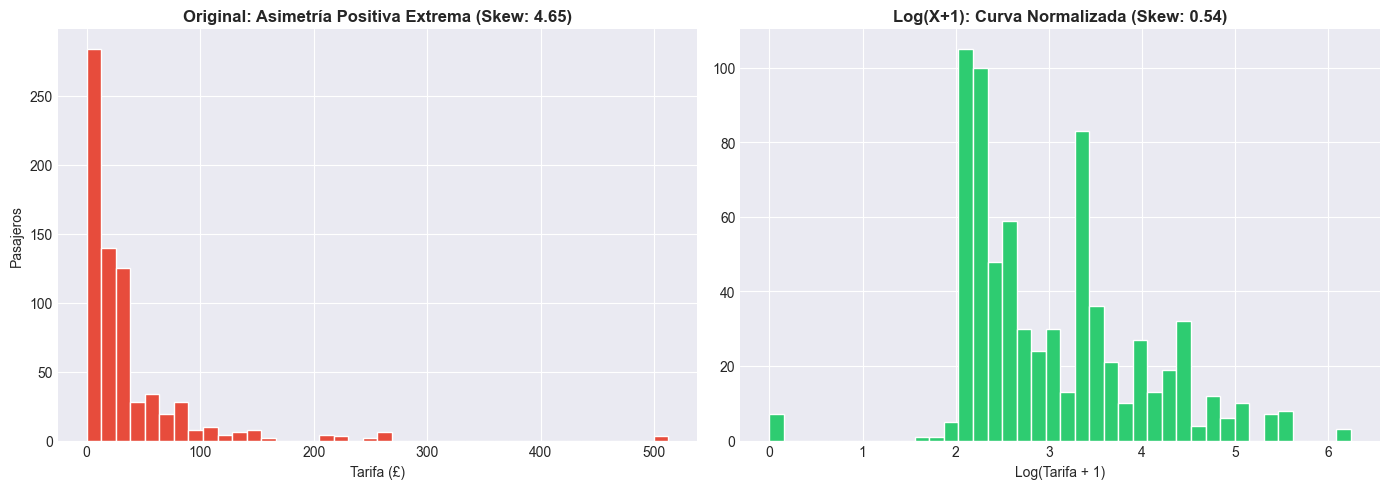

CONCLUSIÓN VISUAL: La gráfica roja concentra todo a la izquierda, es ilegible para regresiones lineales.
La gráfica verde (logaritmo) expande los valores bajos y comprime a los millonarios, revelando una curva de campana matemática mucho más sana para la IA.


In [2]:
# Extrayendo la tarifa
tarifa_original = df['Fare']
# Aplicando transformación logarítmica
tarifa_log = np.log1p(tarifa_original)

# Creando la comparativa visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Asimetría original
ax1.hist(tarifa_original, bins=40, color='#e74c3c', edgecolor='white')
ax1.set_title(f"Original: Asimetría Positiva Extrema (Skew: {tarifa_original.skew():.2f})", fontweight='bold')
ax1.set_xlabel("Tarifa (£)")
ax1.set_ylabel("Pasajeros")

# Gráfica 2: Transformación Logarítmica
ax2.hist(tarifa_log, bins=40, color='#2ecc71', edgecolor='white')
ax2.set_title(f"Log(X+1): Curva Normalizada (Skew: {tarifa_log.skew():.2f})", fontweight='bold')
ax2.set_xlabel("Log(Tarifa + 1)")

plt.tight_layout()
plt.show()

print("CONCLUSIÓN VISUAL: La gráfica roja concentra todo a la izquierda, es ilegible para regresiones lineales.")
print("La gráfica verde (logaritmo) expande los valores bajos y comprime a los millonarios, revelando una curva de campana matemática mucho más sana para la IA.")

---
### Caja Blanca: Las Matemáticas del Logaritmo y el truco `log1p`
En Machine Learning, casi siempre usamos el **Logaritmo Natural** (base $e$), que en NumPy se invoca simplemente como `np.log()`. Matemáticamente, el logaritmo responde a la pregunta: *"¿A qué potencia tengo que elevar la base para obtener este número?"*

Esta operación comprime magnitudes gigantescas. Por ejemplo:
* Para $x = 10$, $\ln(10) \approx 2.30$
* Para $x = 1,000,000$, $\ln(1,000,000) \approx 13.81$

Pasamos de una diferencia de un millón a una diferencia de apenas $11$ unidades en nuestro espacio vectorial. ¡El algoritmo está a salvo!

**El Bug del Cero Absoluto (Zero-Division Error)**
Pero hay un problema arquitectónico grave. ¿Qué pasa si un pasajero del Titanic viajó gratis (Tarifa = $0$) o si una app en la Play Store tiene $0$ descargas? 
El límite del logaritmo cuando $x$ tiende a cero es menos infinito:
$$\lim_{x \to 0} \ln(x) = -\infty$$

Si un solo registro genera un $-\infty$, toda la matriz matemática se corrompe y la Red Neuronal crasheará con un error de `NaN` o `inf`. Veamos cómo solucionar esto en código.

In [3]:
import pandas as pd
import numpy as np

# Creamos un dataset de juguete simulando las descargas de 4 aplicaciones
datos_juguete = pd.DataFrame({
    'App': ['App Escolar', 'Juego Indie', 'App Fantasma', 'WhatsApp'],
    'Descargas': [1000, 5000, 0, 1000000000] # Ojo con el cero de la App Fantasma
})

print("--- 1. El Error del Logaritmo Puro ---")
# Usar np.log() generará un RuntimeWarning por culpa del cero.
with np.errstate(divide='ignore'): # Ocultamos el warning visualmente para el ejemplo
    datos_juguete['Log_Puro'] = np.log(datos_juguete['Descargas'])
print(datos_juguete[['Descargas', 'Log_Puro']])
print("\n¡ALERTA! El procesador devolvió '-inf'. El algoritmo acaba de morir.")

print("\n--- 2. El Parche de Producción: log1p ---")
# np.log1p() calcula matemáticamente log(x + 1)
# Si x es 0 -> log(0 + 1) -> log(1) -> 0. ¡El sistema es estable!
datos_juguete['Log_Seguro'] = np.log1p(datos_juguete['Descargas'])
print(datos_juguete[['Descargas', 'Log_Seguro']])
print("\nCONCLUSIÓN: La asimetría de WhatsApp (1,000 millones) se redujo a un manejable 20.7, y el cero se mantuvo seguro en 0.0.")

--- 1. El Error del Logaritmo Puro ---
    Descargas   Log_Puro
0        1000   6.907755
1        5000   8.517193
2           0       -inf
3  1000000000  20.723266

¡ALERTA! El procesador devolvió '-inf'. El algoritmo acaba de morir.

--- 2. El Parche de Producción: log1p ---
    Descargas  Log_Seguro
0        1000    6.908755
1        5000    8.517393
2           0    0.000000
3  1000000000   20.723266

CONCLUSIÓN: La asimetría de WhatsApp (1,000 millones) se redujo a un manejable 20.7, y el cero se mantuvo seguro en 0.0.


**Regla de Oro en Data Engineering:** 
Siempre que vayas a transformar variables que representan conteos (descargas, número de hijos, visitas) o dinero (tarifas, salarios) donde **el valor cero es una posibilidad real**, tienes estrictamente prohibido usar `np.log()`. Tu estándar de codificación a partir de hoy debe ser usar **`np.log1p()`**.
---

---
### La Maldición de la Dimensionalidad 
La Cardinalidad mide cuántos valores **únicos** tiene una columna. 
Para que un algoritmo aprenda, necesita características donde varios usuarios compartan el mismo valor (patrón). Si una columna tiene un valor distinto por cada usuario, no hay patrón, hay un Identificador (ruido). Veamos cómo se ve esto gráficamente.

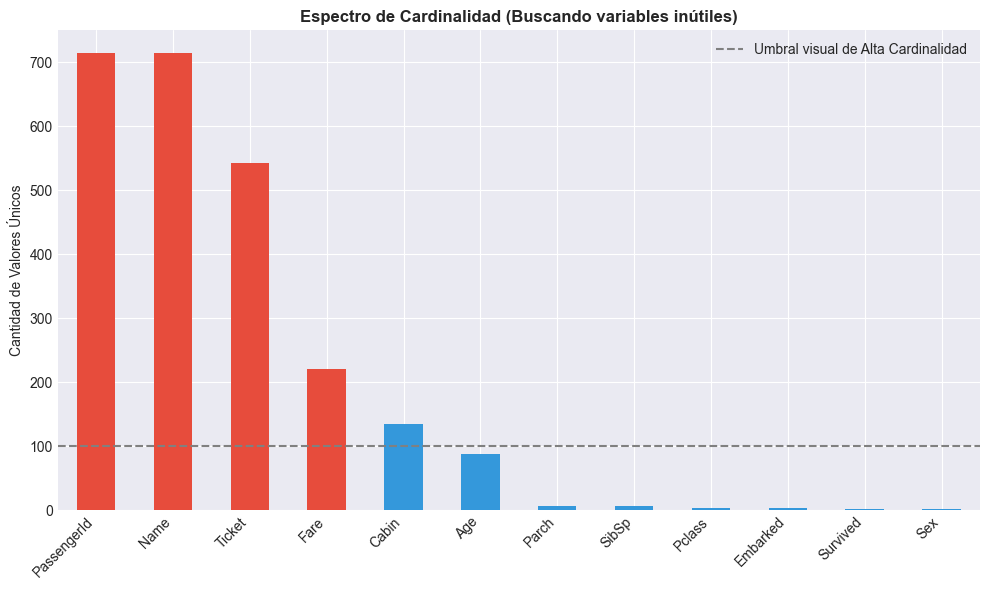

CONCLUSIÓN VISUAL: Las barras rojas (PassengerId, Name, Ticket) tienen casi un valor por fila.
Para un modelo de clasificación, esto no ayuda a predecir, solo provoca memorización masiva (Sobreajuste).


In [4]:
# Calculamos los valores únicos de cada columna y ordenamos de mayor a menor
cardinalidad = df.nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

# Pintamos de rojo las columnas con altísima cardinalidad (potencial ruido tabular) y azul las útiles
colores = ['#e74c3c' if x > 200 else '#3498db' for x in cardinalidad]
cardinalidad.plot(kind='bar', color=colores, ax=ax)

ax.set_title("Espectro de Cardinalidad (Buscando variables inútiles)", fontweight='bold')
ax.set_ylabel("Cantidad de Valores Únicos")
ax.axhline(y=100, color='gray', linestyle='--', label='Umbral visual de Alta Cardinalidad')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("CONCLUSIÓN VISUAL: Las barras rojas (PassengerId, Name, Ticket) tienen casi un valor por fila.")
print("Para un modelo de clasificación, esto no ayuda a predecir, solo provoca memorización masiva (Sobreajuste).")

---
### Caja Blanca: Las 3 Reglas de Oro de la Alta Cardinalidad
¿Cuándo decidimos que una variable tiene "Alta Cardinalidad" y debe ser eliminada o transformada? Como ingenieros, no adivinamos, usamos reglas heurísticas basadas en la proporción de los datos y en la arquitectura de memoria.

**1. La Regla del Ratio de Identidad (> 90%)**
Si divides los valores únicos de una columna entre el total de filas, y el resultado es cercano a 1.0 (o mayor al 90%), estás frente a una Llave Primaria (Primary Key), un UUID, un Hash o un Nombre Completo. 
* *Acción:* **Eliminación inmediata (`.drop`)**. El algoritmo solo memorizará, no generalizará.

**2. La Regla de la Explosión de Memoria (One-Hot Encoding Limit)**
Para que un algoritmo procese categorías (ej. "País"), debemos convertirlas en columnas de ceros y unos. Si tienes una columna con 500 países distintos, tu algoritmo creará 500 columnas nuevas. Si tu RAM no lo soporta o tienes pocas filas, el modelo colapsará (Maldición de la Dimensionalidad).
* *Acción:* La regla general en la industria es que cualquier variable categórica con **más de 50 valores únicos** no debe entrar cruda al modelo. Se debe eliminar o usar técnicas avanzadas como *Target Encoding*.

**3. La Regla de la Cola Larga (The "Other" Binning)**
A veces una columna tiene 100 categorías, pero 3 de ellas concentran el 95% de los usuarios, y las otras 97 categorías solo tienen a una persona. 
* *Acción:* Agrupamos a esas 97 categorías diminutas bajo una sola etiqueta llamada `"Otros"`. Reducimos la cardinalidad de 100 a 4 sin perder la información principal.

Vamos a programar un "Radar de Cardinalidad" para automatizar la Regla 1.

In [5]:
import pandas as pd

# Simulamos un dataset de 1000 pasajeros
total_filas = 1000
datos_juguete = pd.DataFrame({
    'ID_Pasajero': range(1, total_filas + 1),               # 1000 valores únicos
    'Cabina_Hash': [f"A{i}" for i in range(total_filas)],   # 1000 valores únicos
    'Ciudad_Origen': ['Londres', 'Paris'] * 500,            # Solo 2 valores únicos
    'Edad': [25] * total_filas                              # Solo 1 valor único (Varianza Cero)
})

print("--- RADAR AUTOMÁTICO DE CARDINALIDAD ---")

# Definimos nuestro umbral de peligro (ej. más del 50% de unicidad)
umbral_peligro = 0.50 
columnas_a_eliminar = []

for columna in datos_juguete.columns:
    valores_unicos = datos_juguete[columna].nunique()
    ratio = valores_unicos / total_filas
    
    print(f"Columna: {columna.ljust(15)} | Únicos: {valores_unicos} | Ratio: {ratio:.2f}")
    
    # Lógica de decisión
    if ratio > umbral_peligro:
        columnas_a_eliminar.append(columna)

print("\n🚨 Veredicto Arquitectónico 🚨")
print(f"Las siguientes columnas superan el umbral del {umbral_peligro * 100}% y serán purgadas por riesgo de Overfitting:")
print(columnas_a_eliminar)

--- RADAR AUTOMÁTICO DE CARDINALIDAD ---
Columna: ID_Pasajero     | Únicos: 1000 | Ratio: 1.00
Columna: Cabina_Hash     | Únicos: 1000 | Ratio: 1.00
Columna: Ciudad_Origen   | Únicos: 2 | Ratio: 0.00
Columna: Edad            | Únicos: 1 | Ratio: 0.00

🚨 Veredicto Arquitectónico 🚨
Las siguientes columnas superan el umbral del 50.0% y serán purgadas por riesgo de Overfitting:
['ID_Pasajero', 'Cabina_Hash']


**Nota Técnica:** El ratio perfecto depende de la profundidad de tu dataset. En un dataset de 10 millones de filas, tener 1,000 categorías únicas representa un ratio del 0.0001 (0.01%). Es un ratio bajo, pero al intentar convertir esas 1,000 categorías a columnas, la memoria RAM puede agotarse. Siempre auditen el **Ratio de Identidad** y el **Límite Absoluto** de su hardware.
---

---
## Experimentación: Poda de Datos y Compresión Logarítmica
A partir de este punto, trabajarán en equipos sobre el dataset para prepararlo estructuralmente.

### Pregunta A: Auditoría de Asimetría (`.skew()`)
Antes de aplicar matemáticas, debemos probar el estado de los datos.
1. Utilicen el método `.skew()` sobre la columna `Fare` original.
2. Si el valor es mayor a `1.0` o menor a `-1.0`, indica una asimetría altamente severa. ¿Cuál es el valor exacto de la asimetría de la Tarifa y qué nos dice esto empíricamente?

In [7]:
# Escribe tu código aquí:

asimetria = df['Fare'].skew()
print(asimetria)

# RESPUESTA Y ANÁLISIS:
# 4.65, este valor indica que muchos de los valores de la fare se encuentran en los rangos menores, existe un sesgo a la izquierda.

4.6536303678277395


### Pregunta B: Transformación Logarítmica en Producción
Dado que la asimetría es muy alta, vamos a curar la variable.
1. Crea una nueva columna llamada `Fare_Log`.
2. Aplica la función `np.log1p()` de la librería NumPy a la columna `Fare`.
3. Vuelve a calcular el `.skew()` de tu nueva columna `Fare_Log`. Comprueba que el valor bajó dramáticamente acercándose al cero (simetría perfecta).

In [10]:
# Escribe tu código aquí:

df['Fare_Log'] = np.log1p(df['Fare'])

# Comprobación:
print("Nueva Asimetría:", df['Fare_Log'].skew())

Nueva Asimetría: 0.5391934861366324


### Pregunta C: Auditoría de Cardinalidad (Identificando el Ruido)
La cardinalidad es la cantidad de valores **únicos** que tiene una columna. Si una columna tiene casi tantos valores únicos como filas, es un identificador, no un patrón predictivo.
1. Utiliza el método `.nunique()` en todo el *DataFrame* para ver cuántos valores únicos tiene cada columna.
2. Analiza las columnas `PassengerId`, `Name` y `Ticket`. ¿Qué porcentaje aproximado de unicidad tienen respecto al total de pasajeros?

In [12]:
# Escribe tu código aquí:

cardinalidad = df.nunique()
print(cardinalidad)

# RESPUESTA Y ANÁLISIS:
# PassengerId tiene un porcentaje de 100%
# Name tiene un porcentaje de 100%
# Ticket tiene un porcentaje de alrededor del 75%


PassengerId    714
Survived         2
Pclass           3
Name           714
Sex              2
Age             88
SibSp            6
Parch            7
Ticket         542
Fare           220
Cabin          134
Embarked         3
Fare_Log       220
dtype: int64
714
2
3
714
2
88
6
7
542
220
134
3
220


### Pregunta D: Reducción de Dimensionalidad (La Purga)
Como arquitectos, hemos decidido que `PassengerId`, `Name` y `Ticket` son columnas de alta cardinalidad que provocarán sobreajuste. (Nota: Para aprovechar `Name` necesitaríamos procesamiento de lenguaje natural (NLP) para extraer los títulos como 'Mr.' o 'Miss.', pero para modelos tabulares puros, es ruido).
1. Utiliza el método `.drop(columns=[...])` para eliminar **definitivamente** estas tres columnas de tu `df`.
2. Ejecuta `df.info()` para comprobar que el *DataFrame* ahora es más ligero en memoria y dimensionalmente compacto.

In [13]:
# Escribe tu código aquí:

df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Comprobación:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Pclass    714 non-null    int64  
 2   Sex       714 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     714 non-null    int64  
 5   Parch     714 non-null    int64  
 6   Fare      714 non-null    float64
 7   Cabin     185 non-null    object 
 8   Embarked  712 non-null    object 
 9   Fare_Log  714 non-null    float64
dtypes: float64(3), int64(4), object(3)
memory usage: 61.4+ KB
